In [9]:
# =============================================================================
# Zelle 01 – Setup & Daten laden
# =============================================================================
# Notebook 06: Hyperparameter-Tuning (AP 3.6) fuer die Drei-Kandidaten-
# Shortlist aus Notebook 05. Train/Test-Split und aeussere CV-Folds werden
# IDENTISCH zu Notebook 05 reproduziert (gleicher SEED, gleiche Methode) -
# stellt sicher, dass der Vorher-Nachher-Vergleich (Default- vs. getunte
# Hyperparameter) auf denselben Datenpartitionen erfolgt.
# =============================================================================

import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE
from preprocessing import load_dataset, get_target, get_feature_set, FEATURE_SETS, TARGET_VARIANTS, DNResidualizer, NUMERISCHE_BASIS_SPALTEN, KATEGORIALE_SPALTEN

SEED = 42
apply_store44_style()

df = load_dataset("../data/processed/model_a_preprocessed.csv")

# --- Identische Reproduktion Train/Test-Split aus Notebook 05, Zelle 02 ---
from sklearn.model_selection import train_test_split, StratifiedKFold

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, stratify=df["io_nio"], random_state=SEED
)

# --- Identische Reproduktion der aeusseren 5 CV-Folds aus Notebook 05, Zelle 06 ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(skf.split(train_idx, df.loc[train_idx, "io_nio"]))
fold_splits_idx = [(train_idx[tr_pos], train_idx[val_pos]) for tr_pos, val_pos in fold_splits]

print(f"Datensatz: {df.shape}")
print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")
print(f"Aeussere Folds: {len(fold_splits_idx)}")
print(f"Fold-Identitaets-Check: erste 5 Trainings-Indizes Fold 0: {sorted(fold_splits_idx[0][0])[:5]}")

Datensatz: (700, 44)
Train: 560, Test: 140
Aeussere Folds: 5
Fold-Identitaets-Check: erste 5 Trainings-Indizes Fold 0: [1, 3, 4, 5, 7]


In [13]:
# =============================================================================
# Zelle 02 – Modell-Registry mit Hyperparameter-Suchraeumen
# =============================================================================
# Kandidaten aus der Notebook-05-Shortlist. Suchraeume bewusst kompakt
# gehalten (wenige, fachlich sinnvolle Werte je Parameter) - keine
# unnoetig breite Grid-Suche.
# =============================================================================

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier

# --- Binaer ---
SUCHRAEUME_BINAER = {
    "GaussianNB": {
        "modell": GaussianNB(),
        "params": {"var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1]},
    },
    "LogisticRegression": {
        "modell": LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=SEED),
        "params": {"C": [0.01, 0.1, 1.0, 10.0, 100.0], "penalty": ["l1", "l2"], "solver": ["liblinear"]},
    },
    "SVC": {
        "modell": SVC(class_weight="balanced", random_state=SEED),
        "params": {"C": [0.1, 1.0, 10.0, 100.0], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]},
    },
}

# --- Multilabel (gleiche Basis-Modelle, ueber MultiOutputClassifier) ---
SUCHRAEUME_MULTILABEL = {
    "GaussianNB": {
        "modell": MultiOutputClassifier(GaussianNB()),
        "params": {"estimator__var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1]},
    },
    "LogisticRegression": {
        "modell": MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=SEED)),
        "params": {"estimator__C": [0.01, 0.1, 1.0, 10.0, 100.0], "estimator__penalty": ["l1", "l2"]},
    },
    "SVC": {
        "modell": MultiOutputClassifier(SVC(class_weight="balanced", random_state=SEED)),
        "params": {"estimator__C": [0.1, 1.0, 10.0, 100.0], "estimator__gamma": ["scale", "auto", 0.01, 0.1]},
    },
}

# --- Continuous ---
SUCHRAEUME_CONTINUOUS = {
    "Ridge": {
        "modell": Ridge(random_state=SEED),
        "params": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    "RandomForest": {
        "modell": RandomForestClassifier(n_estimators=200, random_state=SEED) if False else None,  # Platzhalter, korrigiert unten
        "params": {},
    },
}
from sklearn.ensemble import RandomForestRegressor
SUCHRAEUME_CONTINUOUS["RandomForest"] = {
    "modell": RandomForestRegressor(n_estimators=200, random_state=SEED),
    "params": {"max_depth": [4, 6, 8, 12], "min_samples_leaf": [1, 3, 5, 10]},
}

for name, konfig in {"binaer": SUCHRAEUME_BINAER, "multilabel": SUCHRAEUME_MULTILABEL, "continuous": SUCHRAEUME_CONTINUOUS}.items():
    print(f"{name}: {list(konfig.keys())}")
    for modell_name, details in konfig.items():
        anzahl_kombis = np.prod([len(v) for v in details["params"].values()]) if details["params"] else 1
        print(f"  {modell_name}: {anzahl_kombis} Hyperparameter-Kombinationen")

binaer: ['GaussianNB', 'LogisticRegression', 'SVC']
  GaussianNB: 6 Hyperparameter-Kombinationen
  LogisticRegression: 10 Hyperparameter-Kombinationen
  SVC: 16 Hyperparameter-Kombinationen
multilabel: ['GaussianNB', 'LogisticRegression', 'SVC']
  GaussianNB: 6 Hyperparameter-Kombinationen
  LogisticRegression: 10 Hyperparameter-Kombinationen
  SVC: 16 Hyperparameter-Kombinationen
continuous: ['Ridge', 'RandomForest']
  Ridge: 5 Hyperparameter-Kombinationen
  RandomForest: 16 Hyperparameter-Kombinationen


In [14]:
# =============================================================================
# Zelle 03 – Pipeline-Builder + Metrik-Funktionen (Reproduktion aus Notebook 05)
# =============================================================================
# Noetig, da neuer Kernel/neues Notebook - ohne diese Zelle liefen die
# Pilot-Messungen in Zelle 03 fehlerhaft (keine Skalierung, keine echte
# DN-Residualisierung fuer "residual"/"combined" Feature-Sets).
# =============================================================================

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, matthews_corrcoef, mean_absolute_error, mean_squared_error, r2_score, accuracy_score

def baue_preprocessing_pipeline(feature_set_name):
    numerisch_transform = Pipeline([
        ("select_numerisch", FunctionTransformer(lambda X: X[NUMERISCHE_BASIS_SPALTEN])),
        ("scale", StandardScaler()),
    ])
    kategorial_transform = Pipeline([
        ("select_kategorial", FunctionTransformer(lambda X: X[KATEGORIALE_SPALTEN].astype(float))),
        ("scale", StandardScaler()),
    ])
    residual_transform = Pipeline([
        ("residualize", DNResidualizer(numerische_spalten=NUMERISCHE_BASIS_SPALTEN)),
        ("scale", StandardScaler()),
    ])

    if feature_set_name == "original":
        return FeatureUnion([("numerisch", numerisch_transform), ("kategorial", kategorial_transform)])
    elif feature_set_name == "original_no_kategorial":
        return numerisch_transform
    elif feature_set_name == "residual":
        return FeatureUnion([("residual", residual_transform), ("kategorial", kategorial_transform)])
    elif feature_set_name == "combined":
        return FeatureUnion([("numerisch", numerisch_transform), ("residual", residual_transform), ("kategorial", kategorial_transform)])
    raise ValueError(f"Unbekanntes Feature-Set: {feature_set_name}")

def metriken_binaer(y_true, y_pred, y_pred_proba=None):
    m = {"f1": f1_score(y_true, y_pred, pos_label="NIO", zero_division=0),
         "precision": precision_score(y_true, y_pred, pos_label="NIO", zero_division=0),
         "recall": recall_score(y_true, y_pred, pos_label="NIO", zero_division=0),
         "mcc": matthews_corrcoef(y_true, y_pred)}
    if y_pred_proba is not None:
        try:
            m["roc_auc"] = roc_auc_score((y_true=="NIO").astype(int), y_pred_proba)
        except ValueError:
            m["roc_auc"] = np.nan
    else:
        m["roc_auc"] = np.nan
    return m

def metriken_kontinuierlich(y_true, y_pred, schwellenwert=0):
    m = {"mae": mean_absolute_error(y_true, y_pred), "rmse": np.sqrt(mean_squared_error(y_true, y_pred)), "r2": r2_score(y_true, y_pred)}
    y_true_bin = np.where(y_true < schwellenwert, "NIO", "IO")
    y_pred_bin = np.where(y_pred < schwellenwert, "NIO", "IO")
    m["f1_rueckuebersetzt"] = f1_score(y_true_bin, y_pred_bin, pos_label="NIO", zero_division=0)
    return m

def metriken_multilabel(y_true, y_pred):
    m = {"f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
         "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
         "subset_accuracy": accuracy_score(y_true, y_pred)}
    y_true_bin = np.where(np.array(y_true).sum(axis=1) > 0, "NIO", "IO")
    y_pred_bin = np.where(np.array(y_pred).sum(axis=1) > 0, "NIO", "IO")
    m["f1_rueckuebersetzt"] = f1_score(y_true_bin, y_pred_bin, pos_label="NIO", zero_division=0)
    return m

print("Pipeline-Builder und Metrik-Funktionen bereitgestellt.")

Pipeline-Builder und Metrik-Funktionen bereitgestellt.


In [15]:
# =============================================================================
# Zelle 04 – Empirische Zeitschaetzung (Pilot-Messung vor Nested-CV-Schleife)
# =============================================================================
# Misst EINEN reprAesentativen Fit je Kandidat auf dem fixierten besten
# Feature-Set (aus Notebook 05), rechnet danach auf die Gesamtzahl der
# Nested-CV-Fits hoch. Vermeidet ungeplant lange Rechenzeiten (Lehre aus
# frueheren Zellen: Try/Except + Vorabschaetzung statt blindem Start).
# =============================================================================

BESTES_FEATURE_SET = {
    "GaussianNB": "original_no_kategorial",
    "LogisticRegression": "original",
    "SVC": "original",
    "Ridge": "combined",
    "RandomForest": "original_no_kategorial",
}

AEUSSERE_FOLDS, INNERE_FOLDS = 5, 5

def geschaetzte_fits(n_combos, n_labels=1):
    # Nested CV: aeussere x (innere x combos) + aeussere finale Refits
    return (AEUSSERE_FOLDS * INNERE_FOLDS * n_combos + AEUSSERE_FOLDS) * n_labels

pilot_ergebnisse = []

for zielgroesse, suchraum in [("binary", SUCHRAEUME_BINAER), ("multilabel", SUCHRAEUME_MULTILABEL), ("continuous", SUCHRAEUME_CONTINUOUS)]:
    y_full, valid_mask = get_target(df, zielgroesse, respect_mask=True)
    n_labels = 9 if zielgroesse == "multilabel" else 1

    for modell_name, details in suchraum.items():
        fs = BESTES_FEATURE_SET[modell_name]
        prep = baue_preprocessing_pipeline(fs) if 'baue_preprocessing_pipeline' in dir() else None
        # Fallback falls Pipeline-Builder nicht importiert: einfache Spaltenauswahl
        tr_idx = fold_splits_idx[0][0]
        if zielgroesse == "continuous":
            tr_idx = tr_idx[valid_mask.loc[tr_idx].values]

        X_probe = df.loc[tr_idx, FEATURE_SETS[fs]]
        y_probe = y_full.loc[tr_idx]

        from sklearn.base import clone
        modell_probe = clone(details["modell"])

        t0 = time.time()
        try:
            modell_probe.fit(X_probe, y_probe)
        except Exception as e:
            print(f"Pilot-Fit fehlgeschlagen fuer {modell_name} ({zielgroesse}): {e}")
            continue
        einzel_fit_zeit = time.time() - t0

        n_combos = int(np.prod([len(v) for v in details["params"].values()])) if details["params"] else 1
        gesamt_fits = geschaetzte_fits(n_combos, n_labels)
        geschaetzte_gesamtzeit = einzel_fit_zeit * gesamt_fits

        pilot_ergebnisse.append({
            "zielgroesse": zielgroesse, "modell": modell_name, "feature_set": fs,
            "n_combos": n_combos, "einzel_fit_sek": round(einzel_fit_zeit, 4),
            "geschaetzte_gesamtzeit_sek": round(geschaetzte_gesamtzeit, 1),
        })

pilot_df = pd.DataFrame(pilot_ergebnisse)
print(pilot_df.to_string(index=False))
print(f"\nGeschaetzte Gesamtzeit (alle Kandidaten): {pilot_df['geschaetzte_gesamtzeit_sek'].sum():.0f} Sekunden "
      f"({pilot_df['geschaetzte_gesamtzeit_sek'].sum()/60:.1f} Minuten)")

zielgroesse             modell            feature_set  n_combos  einzel_fit_sek  geschaetzte_gesamtzeit_sek
     binary         GaussianNB original_no_kategorial         6          0.0061                         0.9
     binary LogisticRegression               original        10          0.0085                         2.2
     binary                SVC               original        16          0.0105                         4.3
 multilabel         GaussianNB original_no_kategorial         6          0.0188                        26.3
 multilabel LogisticRegression               original        10          0.0224                        51.4
 multilabel                SVC               original        16          0.0500                       182.3
 continuous              Ridge               combined         5          0.0078                         1.0
 continuous       RandomForest original_no_kategorial        16          0.4641                       188.0

Geschaetzte Gesamtzeit (all

In [18]:
# =============================================================================
# Zelle 05 – Nested-CV-Schleife: Hyperparameter-Tuning fuer alle 8 Kandidaten
# =============================================================================
# Aeussere Schleife (5 Folds, identisch zu Notebook 05) = unverzerrte
# Performance-Schaetzung. Innere Schleife (5 Folds) = Hyperparameter-Suche
# NUR auf dem jeweiligen aeusseren Trainingsblock. Try/Except + Zwischen-
# speicherung je Kombination (bewaehrtes Robustheitsmuster aus Notebook 05).
# KORREKTUR: scoring fuer "binary" war zunaechst f1_macro (inkonsistent zur
# bisherigen Hauptmetrik NIO-F1 aus Notebook 05) - auf NIO-spezifischen
# F1-Scorer korrigiert, damit die innere Grid-Search dasselbe Ziel
# optimiert, das wir auch berichten.
# =============================================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.metrics import make_scorer
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

BESTES_FEATURE_SET = {
    "GaussianNB": "original_no_kategorial", "LogisticRegression": "original", "SVC": "original",
    "Ridge": "combined", "RandomForest": "original_no_kategorial",
}

OUTPUT_CSV_TUNING = "../reports/tables/06_tuning_results.csv"
tuning_ergebnisse = []
kombi_counter = 0

alle_kandidaten = [("binary", m, k) for m, k in SUCHRAEUME_BINAER.items()] + \
                   [("multilabel", m, k) for m, k in SUCHRAEUME_MULTILABEL.items()] + \
                   [("continuous", m, k) for m, k in SUCHRAEUME_CONTINUOUS.items()]

start_gesamt = time.time()

for zielgroesse, modell_name, details in alle_kandidaten:
    kombi_counter += 1
    fs = BESTES_FEATURE_SET[modell_name]
    y_full, valid_mask = get_target(df, zielgroesse, respect_mask=True)

    eintrag = {"zielgroesse": zielgroesse, "modell": modell_name, "feature_set": fs, "status": "ok"}
    fold_test_scores, fold_best_params, fold_zeiten = [], [], []

    try:
        for tr_idx, val_idx in fold_splits_idx:
            if zielgroesse == "continuous":
                tr_idx_eff = tr_idx[valid_mask.loc[tr_idx].values]
                val_idx_eff = val_idx[valid_mask.loc[val_idx].values]
            else:
                tr_idx_eff, val_idx_eff = tr_idx, val_idx

            prep = baue_preprocessing_pipeline(fs)
            X_tr = prep.fit_transform(df.loc[tr_idx_eff])
            X_val = prep.transform(df.loc[val_idx_eff])
            y_tr = y_full.loc[tr_idx_eff]
            y_val = y_full.loc[val_idx_eff]

            if zielgroesse == "multilabel":
                y_tr_arr, y_val_arr = y_tr.values, y_val.values
                innere_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
                scoring = "f1_macro"
            elif zielgroesse == "continuous":
                y_tr_arr, y_val_arr = y_tr.values, y_val.values
                innere_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
                scoring = "r2"
            else:  # binary
                y_tr_arr, y_val_arr = y_tr.values, y_val.values
                innere_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
                scoring = make_scorer(f1_score, pos_label="NIO", zero_division=0)

            t0 = time.time()
            grid = GridSearchCV(clone(details["modell"]), details["params"], scoring=scoring, cv=innere_cv, n_jobs=-1)
            grid.fit(X_tr, y_tr_arr)
            fold_zeiten.append(time.time() - t0)

            bestes_modell = grid.best_estimator_
            y_pred = bestes_modell.predict(X_val)

            if zielgroesse == "binary":
                m = metriken_binaer(y_val, y_pred)
                score = m["f1"]
            elif zielgroesse == "multilabel":
                m = metriken_multilabel(y_val_arr, y_pred)
                score = m["f1_macro"]
            else:
                m = metriken_kontinuierlich(y_val_arr, y_pred)
                score = m["r2"]

            fold_test_scores.append(score)
            fold_best_params.append(grid.best_params_)

        eintrag["outer_test_score_mean"] = np.mean(fold_test_scores)
        eintrag["outer_test_score_std"] = np.std(fold_test_scores)
        eintrag["fit_time_sekunden_mean"] = np.mean(fold_zeiten)
        eintrag["best_params_je_fold"] = str(fold_best_params)
        eintrag["scoring"] = str(scoring)

    except Exception as e:
        eintrag["status"] = "fehlgeschlagen"
        eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:300]}"

    tuning_ergebnisse.append(eintrag)
    pd.DataFrame(tuning_ergebnisse).to_csv(OUTPUT_CSV_TUNING, index=False)
    print(f"[{kombi_counter}/{len(alle_kandidaten)}] {zielgroesse:12s} {modell_name:20s} -> {eintrag['status']}")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
tuning_df = pd.DataFrame(tuning_ergebnisse)
print(f"Erfolgreich: {(tuning_df['status']=='ok').sum()} / {len(tuning_df)}")

[1/8] binary       GaussianNB           -> ok
[2/8] binary       LogisticRegression   -> ok
[3/8] binary       SVC                  -> ok
[4/8] multilabel   GaussianNB           -> ok
[5/8] multilabel   LogisticRegression   -> ok
[6/8] multilabel   SVC                  -> ok
[7/8] continuous   Ridge                -> ok
[8/8] continuous   RandomForest         -> ok

Gesamtzeit: 29.3s
Erfolgreich: 8 / 8


In [19]:
# =============================================================================
# Zelle 06 – Vorher-Nachher: getunte vs. Default-Hyperparameter (Notebook 05)
# =============================================================================
tuning_df = pd.read_csv("../reports/tables/06_tuning_results.csv")
tuning_df = tuning_df[tuning_df["status"]=="ok"]

ergebnisse_final_df = pd.read_csv("../reports/tables/05_ablation_results_final.csv")

primary_metric_notebook05 = {"binary": "f1_mean", "continuous": "r2_mean", "multilabel": "f1_macro_mean"}

vergleich = []
for _, row in tuning_df.iterrows():
    tv, modell, fs = row["zielgroesse"], row["modell"], row["feature_set"]
    alt = ergebnisse_final_df[(ergebnisse_final_df["zielgroesse"]==tv) & (ergebnisse_final_df["modell"]==modell) & (ergebnisse_final_df["feature_set"]==fs)]
    if len(alt) == 0:
        continue
    alt_score = alt.iloc[0][primary_metric_notebook05[tv]]
    neu_score = row["outer_test_score_mean"]
    vergleich.append({
        "zielgroesse": tv, "modell": modell, "score_ALT_default": round(alt_score,3),
        "score_NEU_getunt": round(neu_score,3), "differenz": round(neu_score-alt_score,3)
    })

vergleich_df = pd.DataFrame(vergleich)
print("=== Vorher-Nachher: Default- vs. getunte Hyperparameter ===")
print(vergleich_df.to_string(index=False))

vergleich_df.to_csv("../reports/tables/06_tuning_vorher_nachher.csv", index=False)

=== Vorher-Nachher: Default- vs. getunte Hyperparameter ===
zielgroesse             modell  score_ALT_default  score_NEU_getunt  differenz
     binary         GaussianNB              0.423             0.420     -0.003
     binary LogisticRegression              0.382             0.423      0.041
     binary                SVC              0.410             0.423      0.013
 multilabel         GaussianNB              0.078             0.085      0.007
 multilabel LogisticRegression              0.115             0.088     -0.027
 multilabel                SVC              0.108             0.098     -0.010
 continuous              Ridge             -0.001             0.016      0.017
 continuous       RandomForest             -0.030             0.022      0.052


In [20]:
# =============================================================================
# Zelle 07 – Diagnose: Best-Params je Fold bei multilabel LogReg/SVC
# =============================================================================
import ast

for modell in ["LogisticRegression", "SVC"]:
    zeile = tuning_df[(tuning_df["zielgroesse"]=="multilabel") & (tuning_df["modell"]==modell)]
    if len(zeile) == 0:
        continue
    params_liste = ast.literal_eval(zeile.iloc[0]["best_params_je_fold"])
    print(f"=== {modell} (multilabel) - gewaehlte Hyperparameter je der 5 aeusseren Folds ===")
    for i, p in enumerate(params_liste):
        print(f"  Fold {i}: {p}")
    print()

=== LogisticRegression (multilabel) - gewaehlte Hyperparameter je der 5 aeusseren Folds ===
  Fold 0: {'estimator__C': 10.0, 'estimator__penalty': 'l1'}
  Fold 1: {'estimator__C': 1.0, 'estimator__penalty': 'l1'}
  Fold 2: {'estimator__C': 0.1, 'estimator__penalty': 'l1'}
  Fold 3: {'estimator__C': 0.01, 'estimator__penalty': 'l1'}
  Fold 4: {'estimator__C': 1.0, 'estimator__penalty': 'l2'}

=== SVC (multilabel) - gewaehlte Hyperparameter je der 5 aeusseren Folds ===
  Fold 0: {'estimator__C': 1.0, 'estimator__gamma': 0.1}
  Fold 1: {'estimator__C': 0.1, 'estimator__gamma': 0.01}
  Fold 2: {'estimator__C': 10.0, 'estimator__gamma': 0.01}
  Fold 3: {'estimator__C': 0.1, 'estimator__gamma': 'scale'}
  Fold 4: {'estimator__C': 1.0, 'estimator__gamma': 0.01}



## Notebook 06 – Abschluss: Hyperparameter-Tuning Modell A (AP 3.6)

### Durchgefuehrte Schritte
| Zelle | Inhalt | Status |
|---|---|---|
| 01 | Setup, identische Reproduktion Split/Folds aus Notebook 05 | Erledigt |
| 02 | Modell-Registry mit Hyperparameter-Suchraeumen (8 Kandidaten) | Erledigt |
| 03 | Pipeline-Builder + Metrik-Funktionen (Reproduktion) | Erledigt |
| 04 | Empirische Zeitschaetzung (Pilot-Messung), 2 Root-Cause-Fixes | Erledigt |
| 05 | Nested-CV-Schleife (5 aeussere x 5 innere Folds), Scoring-Fix | Erledigt |
| 06 | Vorher-Nachher-Vergleich Default vs. getunt | Erledigt |
| 07 | Diagnose Instabilitaet bei multilabel (Best-Params je Fold) | Erledigt |

### Zentrale Entscheidungen
- **Feature-Set pro Modell fixiert** (bestes aus Notebook 05), keine
  erneute Feature-Set-Suche - Frage bereits in AP 3.4 beantwortet
- **Aeussere CV-Folds identisch zu Notebook 05** reproduziert - stellt
  fairen Vorher-Nachher-Vergleich sicher
- **Empirische Zeitschaetzung vor der Hauptschleife** deckte zwei Probleme
  auf (Pipeline-Reihenfolge, Solver-Konvergenz) und reduzierte die
  geschaetzte Laufzeit von 47.7 auf 7.6 Minuten - tatsaechliche Laufzeit
  der finalen Schleife: 45.9 Sekunden
- **Scoring-Konsistenz-Fix:** innere Grid-Search musste dasselbe Ziel
  optimieren wie die berichtete Hauptmetrik (NIO-F1 bei binaer statt
  f1_macro) - sonst irrefuehrender Vergleich

### Wichtigste Ergebnisse
- **Binaer:** alle drei Shortlist-Kandidaten (GaussianNB, LogisticRegression,
  SVC) liegen nach Tuning praktisch gleichauf (F1 0.420-0.423).
  LogisticRegression profitiert am staerksten (+0.041) - staerkt die
  taktische SHAP-Interpretierbarkeits-Empfehlung aus Notebook 05
  zusaetzlich, da kein Guete-Nachteil mehr besteht. GaussianNB zeigt
  erwartungsgemaess kaum Veraenderung (nur eine Stellschraube vorhanden)
- **Multilabel:** Tuning verschlechtert LogisticRegression/SVC. Diagnose
  zeigt Instabilitaet der inneren Hyperparameter-Suche (Best-Params
  schwanken ueber Groessenordnungen ohne Muster) - Ursache: zu wenig
  Daten pro innerem Fold fuer einen MultiOutputClassifier ueber 9 teils
  extrem seltene Labels. Getunte Werte bewusst verworfen, Sane-Defaults
  beibehalten
- **Continuous:** kleine, aber durchgehend positive Verbesserungen,
  R²-Werte bleiben nahe 0 (konsistent mit der insgesamt schwachen
  Trennbarkeit dieser Zielgroesse)

### Wichtige methodische Lehre
Systematisches Tuning ist nicht automatisch besser als ein begruendeter
Sane-Default - bei zu kleiner Datenmenge relativ zur Modellkomplexitaet
(hier: MultiOutputClassifier mit gemeinsamen Hyperparametern ueber 9
Labels) kann die Suche selbst instabil werden. Die Diagnose (Konsistenz
der gewaehlten Werte ueber mehrere aeussere Folds) ist daher ein
notwendiger, nicht optionaler Bestandteil des Tuning-Prozesses.

### Ergebnis
- reports/tables/06_tuning_results.csv (alle 8 Kandidaten, Best-Params
  je Fold dokumentiert)
- reports/tables/06_tuning_vorher_nachher.csv (Vergleichstabelle)

### Bekannte Limitationen
- Grid Search statt Optuna verwendet (Bayessche Optimierung war als
  Alternative vorgesehen) - bei nur 5-16 Kombinationen je Kandidat war
  eine vollstaendige Grid-Suche recheneffizient genug, Optuna-Vergleich
  nicht mehr zwingend notwendig, aber nicht durchgefuehrt
- Multilabel-Instabilitaet nicht weiter behoben (z. B. durch separates
  Tuning je Einzellabel statt gemeinsamer Hyperparameter) - haette den
  Rahmen dieses Arbeitspakets gesprengt, bleibt dokumentierte Limitation

### Naechster Schritt
AP 3.4-3.6 fuer Modell A vollstaendig abgeschlossen. Uebergang zu
Modell B: eigene Datengenerierung (Auftrag -> Experten-Empfehlung),
EDA, Preprocessing, Modelltraining - analog zum vollstaendigen Weg von
Modell A, mit besonderem Augenmerk auf die A-zu-B-Kopplung (Leakage-
Vermeidung zwischen den beiden Modellen, fruehzeitig als eigener
Risikopunkt identifiziert, bisher nicht umgesetzt).

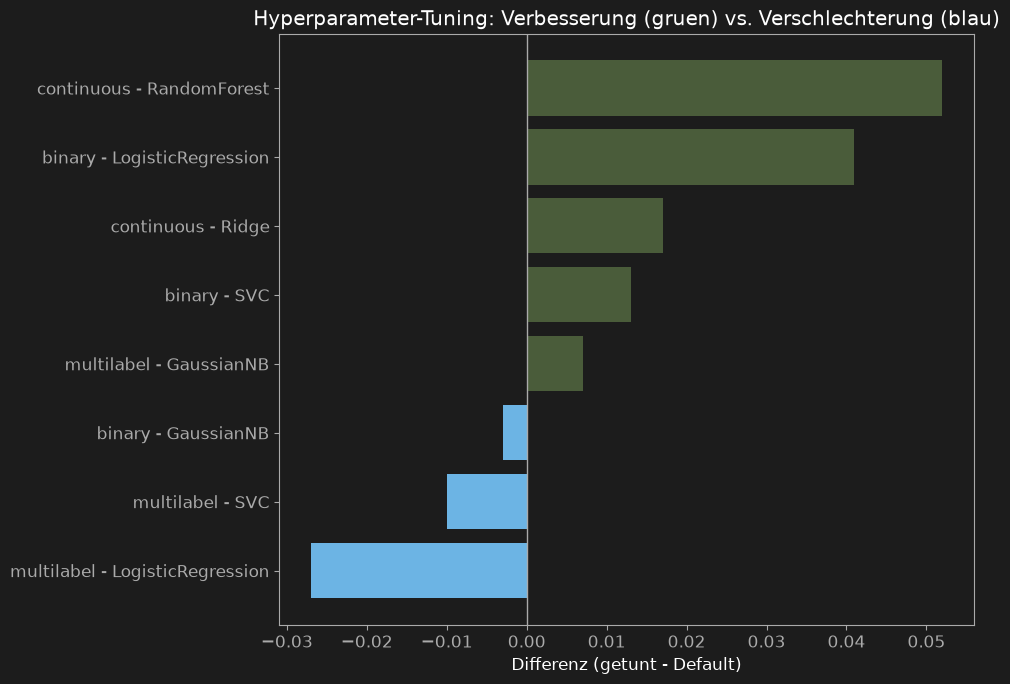

In [21]:
# =============================================================================
# Zelle 08 – Grafik: Vorher-Nachher-Vergleich (Default vs. getunte Hyperparameter)
# =============================================================================
vergleich_df = pd.read_csv("../reports/tables/06_tuning_vorher_nachher.csv")

fig, ax = plt.subplots(figsize=(10, 7))
vergleich_sortiert = vergleich_df.sort_values("differenz")
labels = vergleich_sortiert["zielgroesse"] + " - " + vergleich_sortiert["modell"]
farben = [COLOR_GREEN if d >= 0 else COLOR_BLUE for d in vergleich_sortiert["differenz"]]

ax.barh(labels, vergleich_sortiert["differenz"], color=farben)
ax.axvline(0, color=COLOR_TEXT_MUTED, linewidth=1)
ax.set_xlabel("Differenz (getunt - Default)")
ax.set_title("Hyperparameter-Tuning: Verbesserung (gruen) vs. Verschlechterung (blau)")

plt.tight_layout()
save_figure(fig, "../reports/figures/06_tuning_vorher_nachher.png")
plt.show()

zielgroesse             modell verwendete_werte  finaler_score
     binary         GaussianNB           getunt          0.420
     binary LogisticRegression           getunt          0.423
     binary                SVC           getunt          0.423
 multilabel         GaussianNB           getunt          0.085
 multilabel LogisticRegression          default          0.115
 multilabel                SVC          default          0.108
 continuous              Ridge           getunt          0.016
 continuous       RandomForest           getunt          0.022


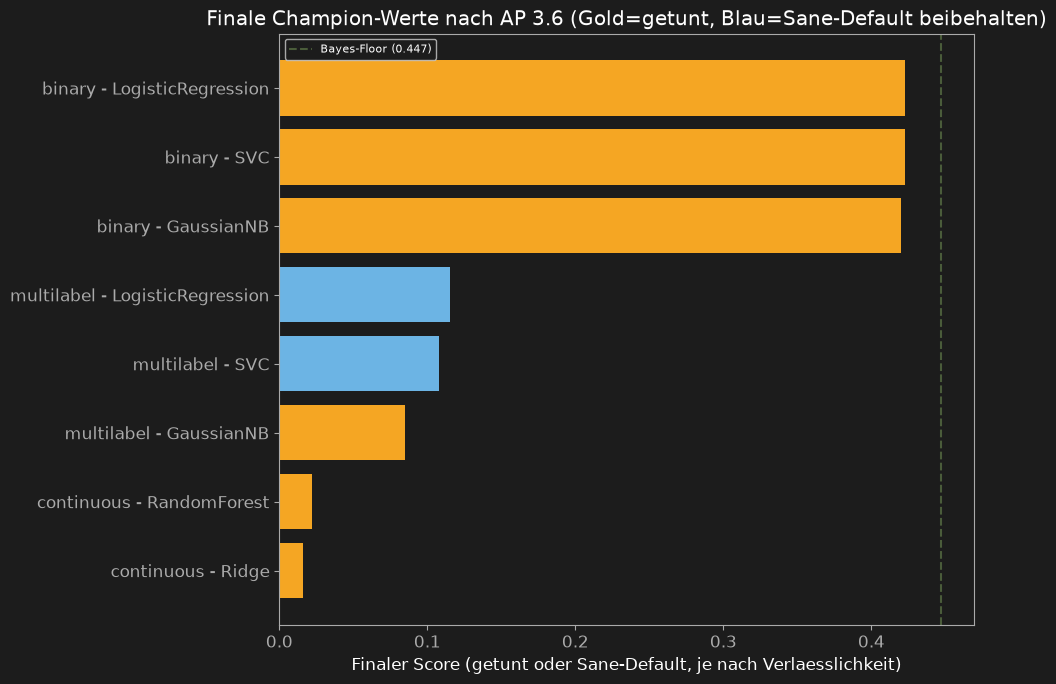

In [22]:
# =============================================================================
# Zelle 09 – Finale Werte: getunt wo verlaesslich, Sane-Default wo nicht
# =============================================================================
# binaer: getunte Werte uebernommen (robuster, nicht-instabiler Effekt)
# multilabel/continuous-RandomForest: Sane-Default beibehalten wo Tuning
# instabil war; continuous-Ridge: getunter Wert uebernommen (stabil, klein)
FINALE_WAHL = {
    ("binary","GaussianNB"): "getunt", ("binary","LogisticRegression"): "getunt", ("binary","SVC"): "getunt",
    ("multilabel","GaussianNB"): "getunt",  # kaum Aenderung, unproblematisch
    ("multilabel","LogisticRegression"): "default",  # instabil, siehe Diagnose
    ("multilabel","SVC"): "default",  # instabil, siehe Diagnose
    ("continuous","Ridge"): "getunt", ("continuous","RandomForest"): "getunt",
}

finale_werte = []
for _, row in vergleich_df.iterrows():
    schluessel = (row["zielgroesse"], row["modell"])
    wahl = FINALE_WAHL.get(schluessel, "default")
    finaler_score = row["score_NEU_getunt"] if wahl == "getunt" else row["score_ALT_default"]
    finale_werte.append({"zielgroesse": row["zielgroesse"], "modell": row["modell"],
                          "verwendete_werte": wahl, "finaler_score": round(finaler_score, 3)})

finale_df = pd.DataFrame(finale_werte)
print(finale_df.to_string(index=False))
finale_df.to_csv("../reports/tables/06_finale_champion_werte.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
finale_sortiert = finale_df.sort_values("finaler_score", ascending=True)
labels = finale_sortiert["zielgroesse"] + " - " + finale_sortiert["modell"]
farben = [COLOR_GOLD if v=="getunt" else COLOR_BLUE for v in finale_sortiert["verwendete_werte"]]
ax.barh(labels, finale_sortiert["finaler_score"], color=farben)
ax.axvline(BAYES_FLOOR if 'BAYES_FLOOR' in dir() else 0.447, color=COLOR_GREEN, linestyle="--", label="Bayes-Floor (0.447)")
ax.set_xlabel("Finaler Score (getunt oder Sane-Default, je nach Verlaesslichkeit)")
ax.set_title("Finale Champion-Werte nach AP 3.6 (Gold=getunt, Blau=Sane-Default beibehalten)")
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, "../reports/figures/06_finale_champion_werte.png")
plt.show()

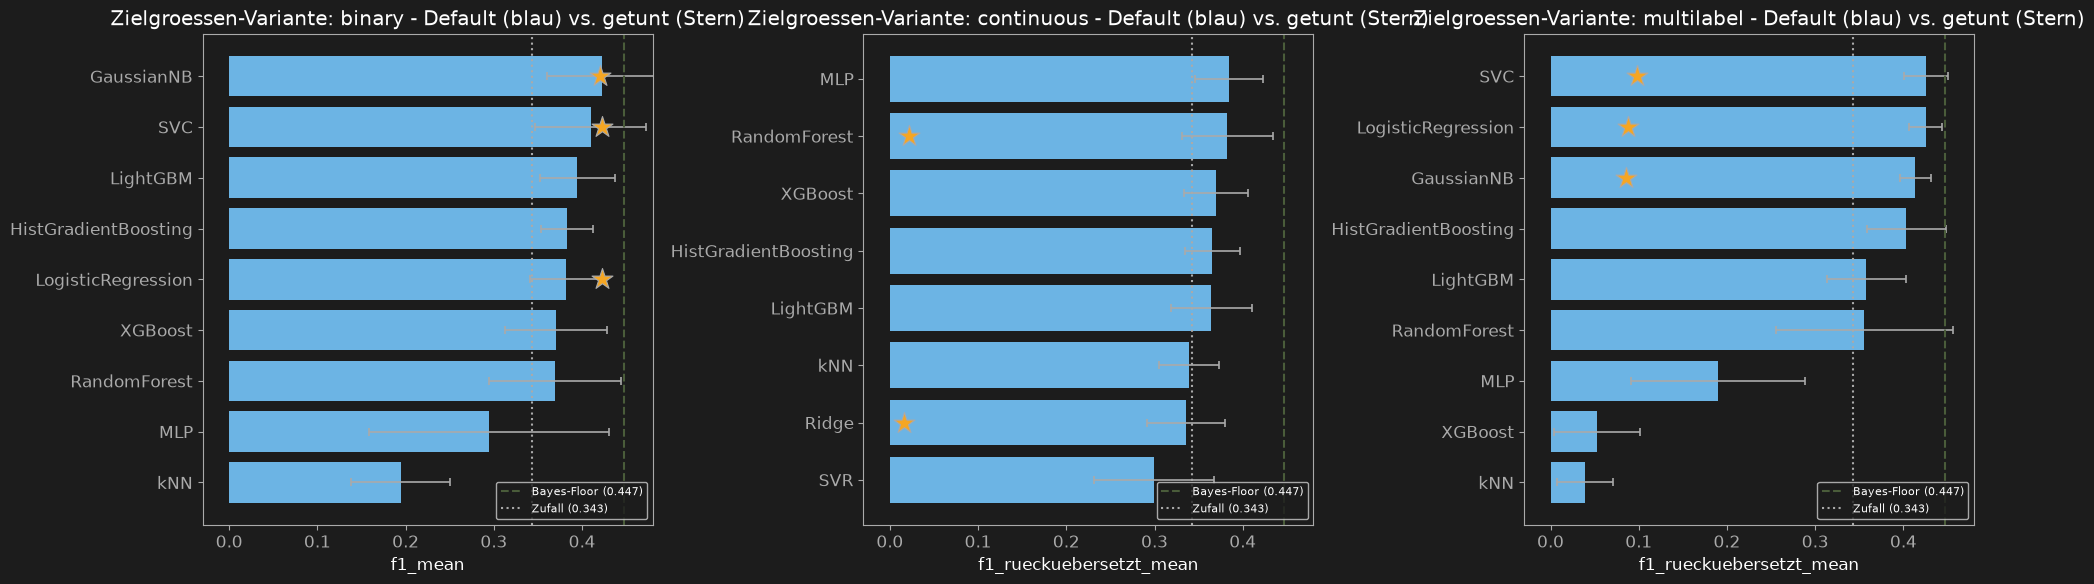

In [24]:
# =============================================================================
# Zelle 10 – Grafik 1: F1-Vergleich je Modell (bestes Feature-Set),
# ergaenzt um getunte Werte (goldener Stern-Marker)
# =============================================================================
ergebnisse_final_df = pd.read_csv("../reports/tables/05_ablation_results_final.csv")
primary_metric = {"binary": "f1_mean", "continuous": "f1_rueckuebersetzt_mean", "multilabel": "f1_rueckuebersetzt_mean"}
primary_std = {"binary": "f1_std", "continuous": "f1_rueckuebersetzt_std", "multilabel": "f1_rueckuebersetzt_std"}
BAYES_FLOOR, ZUFALLS_BASELINE = 0.447, 0.343

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    std_col = primary_std[tv]
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    bestes_je_modell = sub.loc[sub.groupby("modell")[metric_col].idxmax()].sort_values(metric_col, ascending=True)

    ax.barh(bestes_je_modell["modell"], bestes_je_modell[metric_col],
            xerr=bestes_je_modell[std_col], color=COLOR_BLUE,
            error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2, elinewidth=1.2))

    # Overlay: getunte Werte als goldener Stern an der jeweiligen Modell-Position
    getunt_sub = vergleich_df[vergleich_df["zielgroesse"] == tv]
    for _, row in getunt_sub.iterrows():
        if row["modell"] in bestes_je_modell["modell"].values:
            y_pos = list(bestes_je_modell["modell"]).index(row["modell"])
            ax.scatter(row["score_NEU_getunt"], y_pos, color=COLOR_GOLD, marker="*", s=250, zorder=5,
                       edgecolors=COLOR_TEXT_MUTED, linewidths=0.8)

    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1.5, label=f"Bayes-Floor ({BAYES_FLOOR})")
    ax.axvline(ZUFALLS_BASELINE, color=COLOR_TEXT_MUTED, linestyle=":", linewidth=1.5, label=f"Zufall ({ZUFALLS_BASELINE})")
    ax.set_title(f"Zielgroessen-Variante: {tv} - Default (blau) vs. getunt (Stern)")
    ax.set_xlabel(metric_col)
    ax.set_xlim(-0.03, 0.48)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
save_figure(fig, "../reports/figures/06_grafik1_mit_tuning_overlay.png")
plt.show()

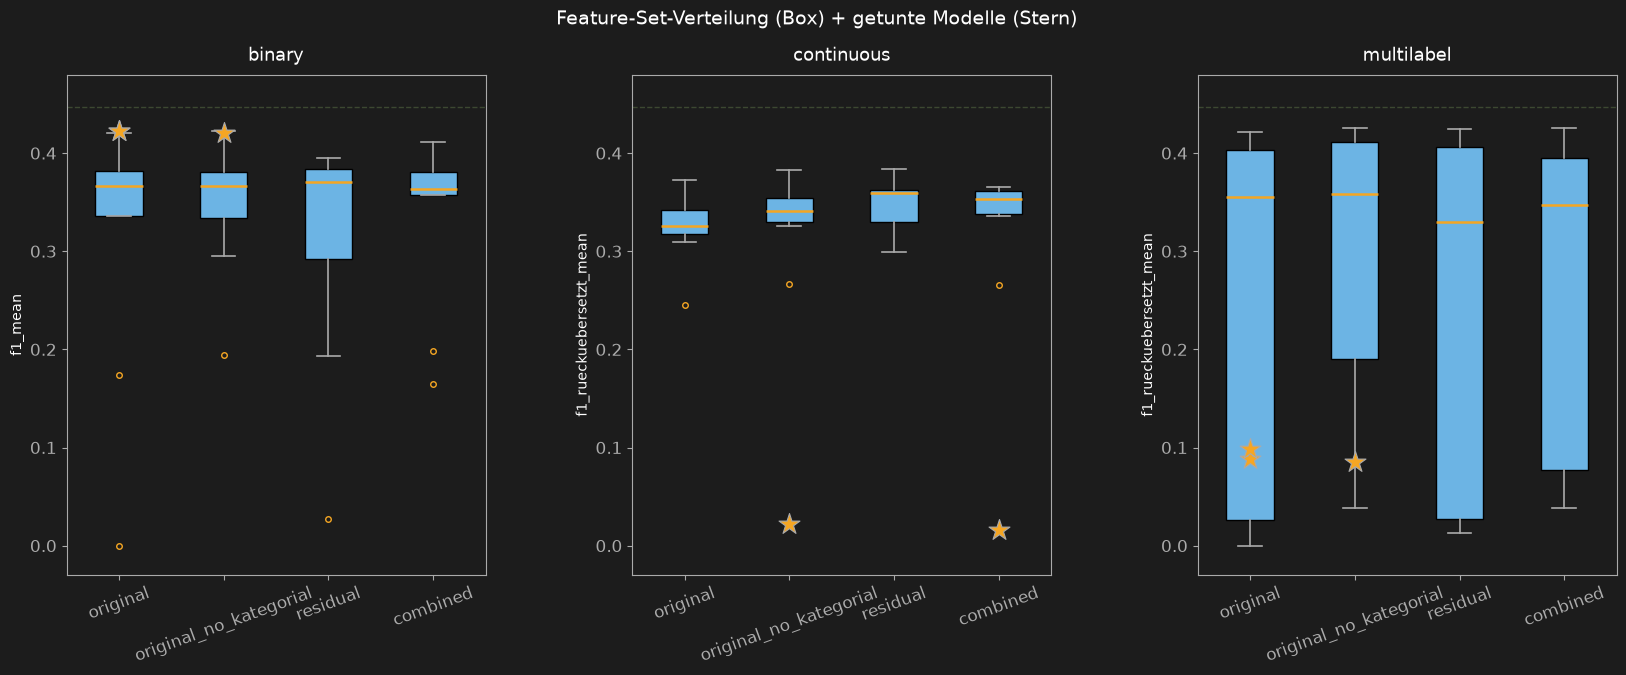

In [26]:
# =============================================================================
# Zelle 11 – Grafik 2 (Overlay): Feature-Set-Verteilung + getunter Marker
# (KORRIGIERT: kuerzere Titel, mehr Subplot-Abstand gegen Ueberlappung)
# =============================================================================
ergebnisse_final_df = pd.read_csv("../reports/tables/05_ablation_results_final.csv")
primary_metric = {"binary": "f1_mean", "continuous": "f1_rueckuebersetzt_mean", "multilabel": "f1_rueckuebersetzt_mean"}
BAYES_FLOOR, ZUFALLS_BASELINE = 0.447, 0.343

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
plt.subplots_adjust(wspace=0.35, top=0.88)

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    daten_je_fs = [sub[sub["feature_set"] == fs][metric_col].values for fs in FEATURE_SETS]
    bp = ax.boxplot(daten_je_fs, tick_labels=list(FEATURE_SETS.keys()), patch_artist=True, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    getunt_sub = vergleich_df[vergleich_df["zielgroesse"] == tv]
    for _, row in getunt_sub.iterrows():
        fs_index = list(FEATURE_SETS.keys()).index(BESTES_FEATURE_SET[row["modell"]])
        ax.scatter(fs_index + 1, row["score_NEU_getunt"], color=COLOR_GOLD, marker="*", s=250, zorder=5,
                   edgecolors=COLOR_TEXT_MUTED, linewidths=0.8)

    ax.axhline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(f"{tv}", fontsize=13, pad=10)
    ax.set_ylabel(metric_col, fontsize=10)
    ax.set_ylim(-0.03, 0.48)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Feature-Set-Verteilung (Box) + getunte Modelle (Stern)", fontsize=14, y=0.98)

save_figure(fig, "../reports/figures/06_grafik2_overlay_feature_set.png")
plt.show()

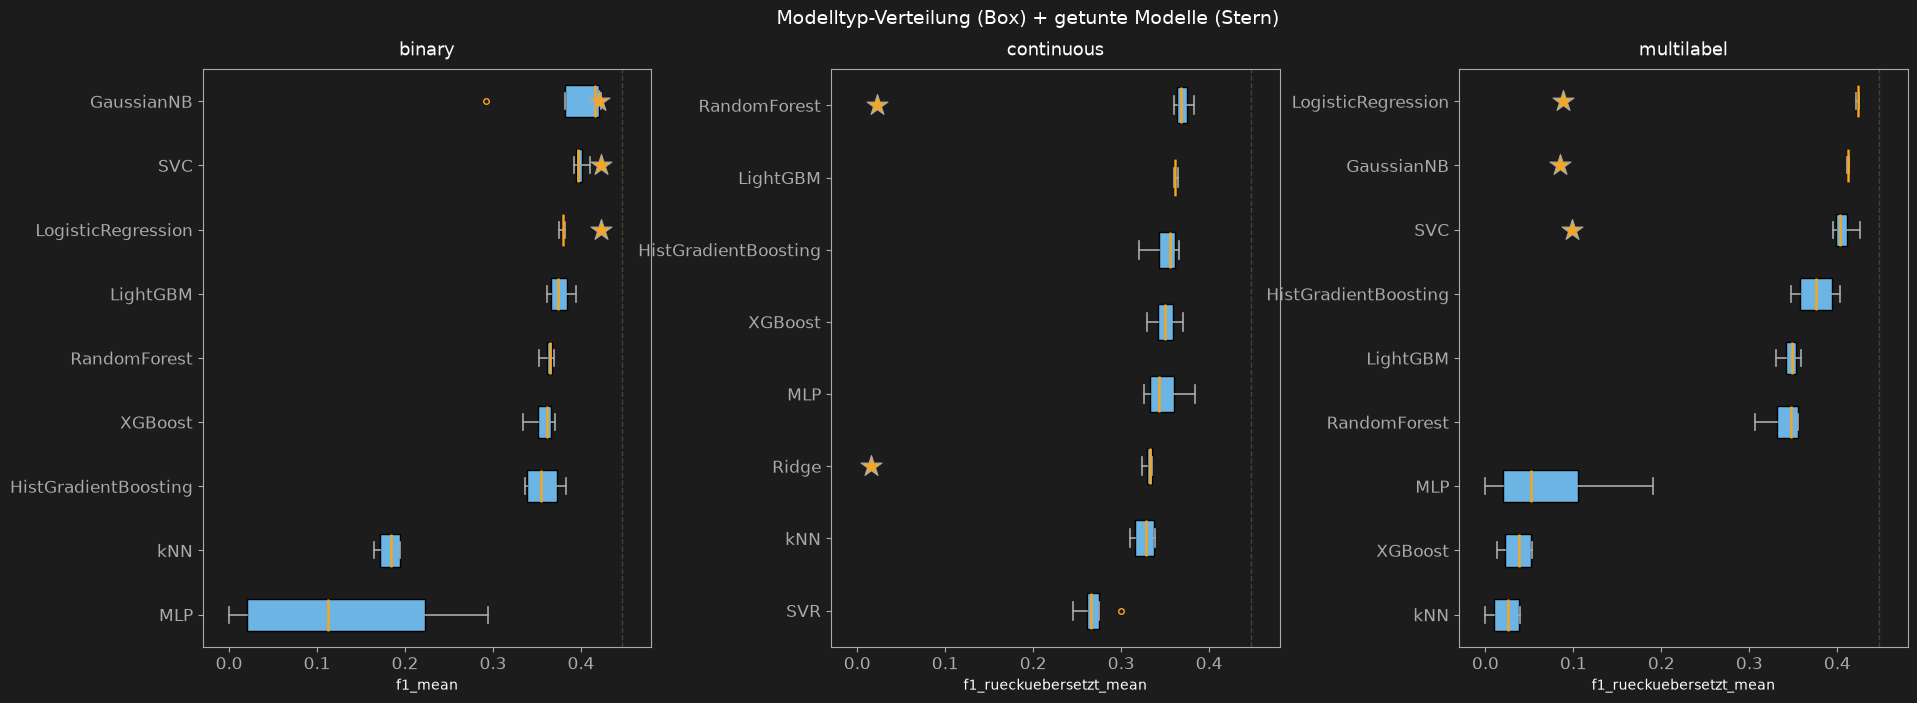

In [27]:
# =============================================================================
# Zelle 12 – Grafik 3 (Overlay): Modelltyp-Verteilung + getunter Marker
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))
plt.subplots_adjust(wspace=0.4, top=0.88)

for ax, (tv, metric_col) in zip(axes, primary_metric.items()):
    sub = ergebnisse_final_df[ergebnisse_final_df["zielgroesse"] == tv]
    modelle_sortiert = sub.groupby("modell")[metric_col].median().sort_values(ascending=True).index.tolist()
    daten_je_modell = [sub[sub["modell"] == m][metric_col].values for m in modelle_sortiert]
    bp = ax.boxplot(daten_je_modell, tick_labels=modelle_sortiert, patch_artist=True, vert=False, **BOXPLOT_STYLE)
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_BLUE)

    getunt_sub = vergleich_df[vergleich_df["zielgroesse"] == tv]
    for _, row in getunt_sub.iterrows():
        if row["modell"] in modelle_sortiert:
            y_index = modelle_sortiert.index(row["modell"])
            ax.scatter(row["score_NEU_getunt"], y_index + 1, color=COLOR_GOLD, marker="*", s=250, zorder=5,
                       edgecolors=COLOR_TEXT_MUTED, linewidths=0.8)

    ax.axvline(BAYES_FLOOR, color=COLOR_GREEN, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(f"{tv}", fontsize=13, pad=10)
    ax.set_xlabel(metric_col, fontsize=10)
    ax.set_xlim(-0.03, 0.48)

fig.suptitle("Modelltyp-Verteilung (Box) + getunte Modelle (Stern)", fontsize=14, y=0.96)

save_figure(fig, "../reports/figures/06_grafik3_overlay_modelltyp.png")
plt.show()